
📥 Downloading price data...
✅ 5 tickers loaded.
   Date range: 2022-01-04 → 2026-03-26
   136 trading days of return data

  ANNUALISED INPUT STATISTICS
  Asset                       Return      Vol   Sharpe
-----------------------------------------------------------------
  VWRP                          9.0%     10.7%      0.42
  XLVS (Healthcare)            14.8%     14.4%      0.71
  DEFS (EU Defence)            -3.5%     27.2%     -0.29
  META (Ind. Metals)           21.1%     18.0%      0.92
  WT Quantum (QWTM)            32.7%     37.9%      0.75

🎲 Running Monte Carlo with 10,000 portfolios...
   Best Monte Carlo Sharpe: 1.004

  PROJECT 3 — POSITION SIZING RESULTS

  Asset                       Equal Wt  Risk Parity        MVO
---------------------------------------------------------------------------
  VWRP                           20.0%         27.5%       50.0%
  XLVS (Healthcare)              20.0%         30.2%       13.5%
  DEFS (EU Defence)              20.0%         1

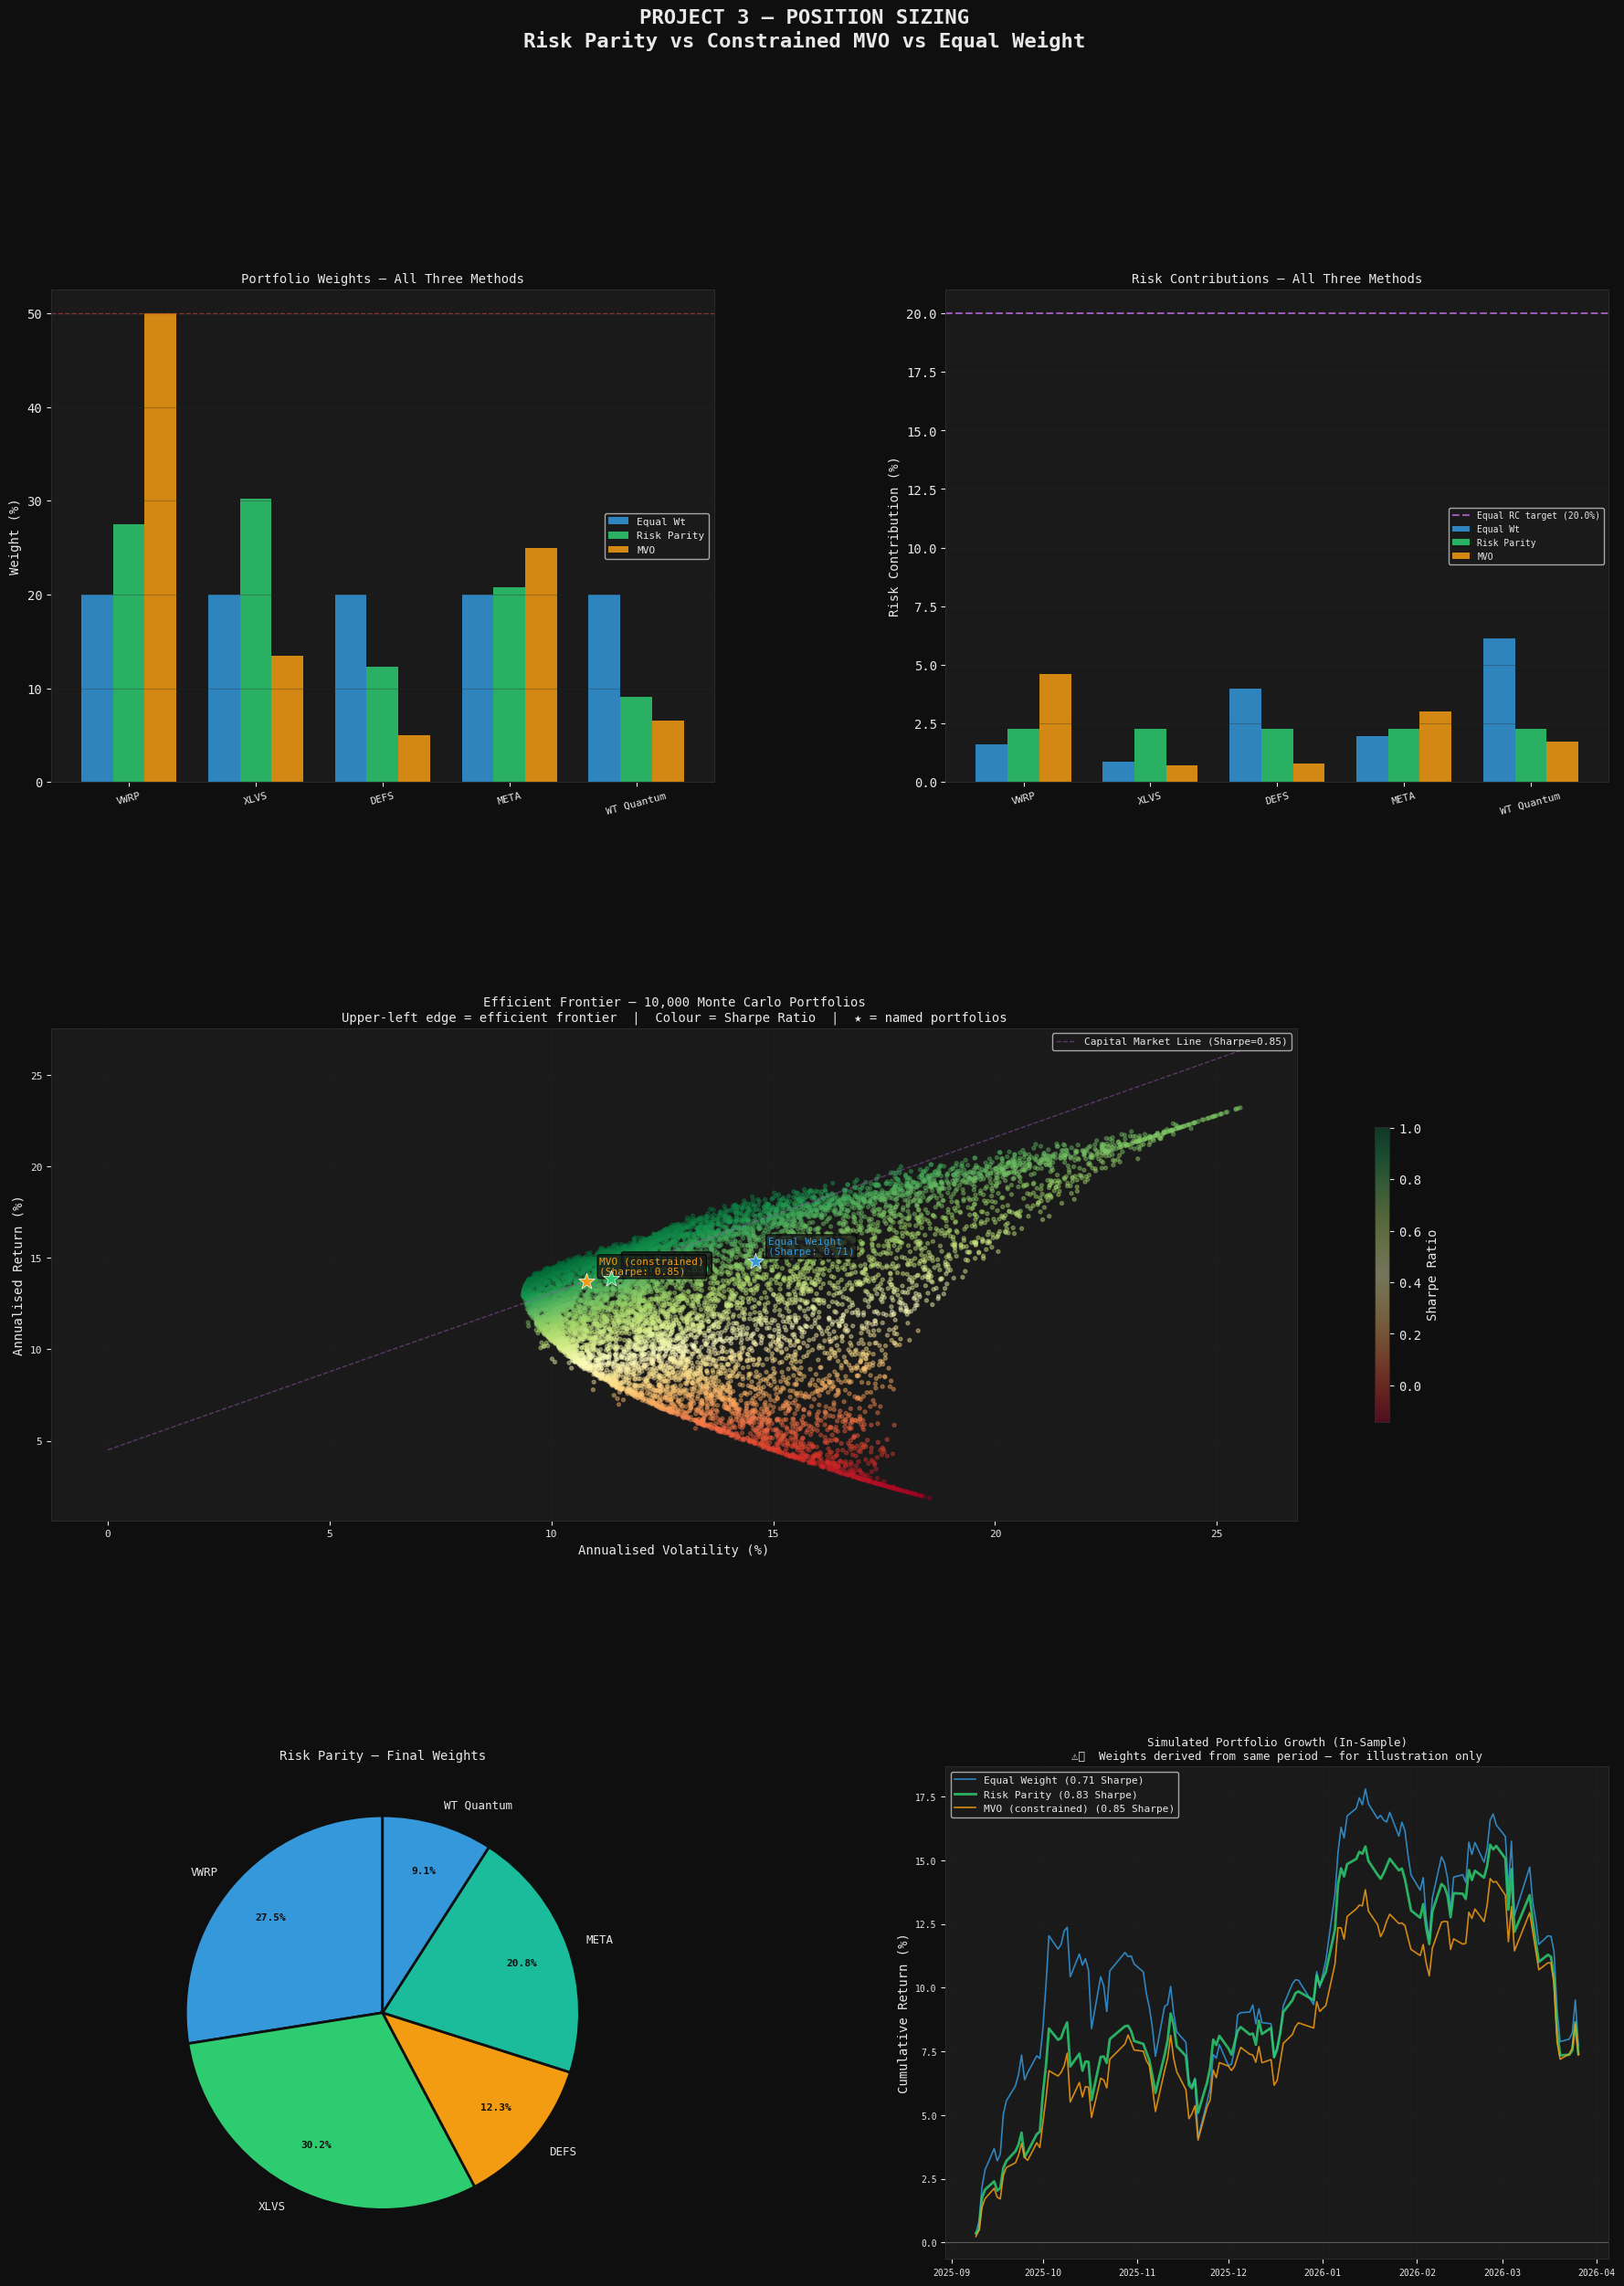


╔══════════════════════════════════════════════════════════════╗
║  PROJECT 3 COMPLETE — YOUR OPTIMAL ALLOCATION                ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  REMEMBER:                                                   ║
║  Risk Parity output is your STRUCTURAL BASELINE.             ║
║  MVO output is DIRECTIONAL GUIDANCE only.                    ║
║  Both are derived from short data — treat as framework,      ║
║  not precise instruction.                                    ║
║                                                              ║
║  Revisit with 2+ years of satellite data for reliable        ║
║  MVO inputs. The framework is now built. Let time            ║
║  fill in the data.                                           ║
║                                                              ║
║  PIPELINE COMPLETE:                                          ║
║  Filter 0 (Cost) → Fil

In [2]:
"""
============================================================
 PROJECT 3 — POSITION SIZING
 Clark's T212 Satellite Portfolio vs VWRP Backbone
============================================================

PIPELINE POSITION:
  Final stage. Receives survivors from Project 2.
  Outputs optimal position sizes using two methods.

METHODS:
  Risk Parity  → size by inverse volatility
                 robust, no return estimates needed
                 default recommendation

  Constrained MVO → Markowitz mean-variance optimisation
                    with weight bounds to prevent corner solutions
                    directional guidance, not precise instruction

SURVIVORS FROM PROJECT 2:
  VWRP  → Backbone (global market exposure)
  XLVS  → Healthcare S&P (low corr, positive skew)
  DEFS  → EU Defence (structural conviction override)
  META  → Industrial Metals Enhanced (transition thesis)

KEY CONCEPTS:
  Efficient Frontier  → set of portfolios maximising
                        return per unit of risk
  Covariance Matrix   → captures both individual volatilities
                        AND pairwise correlations
                        the mathematical heart of MVO
  Risk Contribution   → each asset's share of total
                        portfolio variance
                        Risk Parity equalises this
  Sharpe Ratio        → objective function MVO maximises
  Monte Carlo         → simulate thousands of random portfolios
                        to visualise the efficient frontier
============================================================
"""

# ── IMPORTS ──────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')


# ══════════════════════════════════════════════════════════
#  CONFIGURATION
# ══════════════════════════════════════════════════════════

# Project 2 survivors — tickers and short names
SURVIVORS = {
    'VWRP.L':  'VWRP',
    'XLVS.L':  'XLVS (Healthcare)',
    'DEFS.L':  'DEFS (EU Defence)',
    'META.L':  'META (Ind. Metals)',
    'QWTM.L':  'WT Quantum (QWTM)',
}

BACKBONE      = 'VWRP.L'
START_DATE    = '2022-01-01'
END_DATE      = '2026-03-27'

RISK_FREE_RATE = 0.045    # UK base rate ~early 2026, annualised

# ── MVO Constraints ───────────────────────────────────────
# These prevent corner solutions and reflect your
# deliberate portfolio architecture decisions.

VWRP_MIN      = 0.50    # VWRP is the backbone — never below 50%
VWRP_MAX      = 0.85    # Leave room for meaningful satellite exposure
SAT_MIN       = 0.05    # Each satellite must be at least 5%
                         # Below this it has no real portfolio impact
SAT_MAX       = 0.25    # No single satellite dominates

# ── Monte Carlo ───────────────────────────────────────────
N_PORTFOLIOS  = 10_000  # Random portfolios to simulate the frontier

# ── Style ─────────────────────────────────────────────────
PALETTE = {
    'background': '#0f0f0f',
    'panel':      '#1a1a1a',
    'text':       '#e8e8e8',
    'green':      '#2ecc71',
    'amber':      '#f39c12',
    'red':        '#e74c3c',
    'blue':       '#3498db',
    'purple':     '#9b59b6',
    'cyan':       '#1abc9c',
    'grid':       '#2a2a2a',
}

plt.rcParams.update({
    'figure.facecolor': PALETTE['background'],
    'axes.facecolor':   PALETTE['panel'],
    'axes.edgecolor':   PALETTE['grid'],
    'axes.labelcolor':  PALETTE['text'],
    'xtick.color':      PALETTE['text'],
    'ytick.color':      PALETTE['text'],
    'text.color':       PALETTE['text'],
    'grid.color':       PALETTE['grid'],
    'font.family':      'monospace',
})


# ══════════════════════════════════════════════════════════
#  STEP 1 — DOWNLOAD & PREPARE DATA
# ══════════════════════════════════════════════════════════

print("\n📥 Downloading price data...")

tickers = list(SURVIVORS.keys())
raw = yf.download(
    tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)['Close']

if isinstance(raw, pd.Series):
    raw = raw.to_frame()

available = [t for t in tickers
             if t in raw.columns and raw[t].notna().sum() > 30]

prices = raw[available].dropna(how='all')
short  = {t: SURVIVORS[t] for t in available}
prices.rename(columns=short, inplace=True)

backbone_name = SURVIVORS[BACKBONE]
names         = list(prices.columns)
n             = len(names)

returns       = prices.pct_change().dropna()

print(f"✅ {len(available)} tickers loaded.")
print(f"   Date range: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"   {len(returns)} trading days of return data\n")


# ══════════════════════════════════════════════════════════
#  STEP 2 — ANNUALISED STATISTICS
# ══════════════════════════════════════════════════════════
# These are the INPUTS to both optimisers.
# Quality of outputs is bounded by quality of inputs.
# On short data, treat these as directional estimates,
# not precise forecasts.

ann_returns = returns.mean() * 252        # Annualised expected return
ann_vols    = returns.std()  * np.sqrt(252)  # Annualised volatility

# Covariance matrix — the mathematical heart of MVO.
# Σ[i,j] = cov(rᵢ, rⱼ) = ρᵢⱼ × σᵢ × σⱼ
# Captures both individual risk AND pairwise interactions.
# Annualised by multiplying daily cov × 252.
cov_matrix  = returns.cov() * 252

print("=" * 65)
print("  ANNUALISED INPUT STATISTICS")
print("=" * 65)
print(f"  {'Asset':<25} {'Return':>8} {'Vol':>8} {'Sharpe':>8}")
print("-" * 65)
for name in names:
    r  = ann_returns[name]
    v  = ann_vols[name]
    sh = (r - RISK_FREE_RATE) / v if v > 0 else np.nan
    print(f"  {name:<25} {r*100:>7.1f}%  {v*100:>7.1f}%  {sh:>8.2f}")
print("=" * 65)


# ══════════════════════════════════════════════════════════
#  STEP 3 — PORTFOLIO METRIC HELPERS
# ══════════════════════════════════════════════════════════

def portfolio_return(weights, ann_returns):
    """wᵀμ — weighted sum of expected returns"""
    return np.dot(weights, ann_returns)

def portfolio_vol(weights, cov_matrix):
    """sqrt(wᵀΣw) — portfolio standard deviation
    
    This is where diversification lives mathematically.
    When assets are correlated, wᵀΣw < Σwᵢ²σᵢ²
    The cross terms (covariances) reduce total variance
    below the weighted sum of individual variances.
    This is Markowitz's 'free lunch'.
    """
    return np.sqrt(np.dot(weights, np.dot(cov_matrix, weights)))

def portfolio_sharpe(weights, ann_returns, cov_matrix, rf=RISK_FREE_RATE):
    """(wᵀμ - rf) / sqrt(wᵀΣw)"""
    r = portfolio_return(weights, ann_returns)
    v = portfolio_vol(weights, cov_matrix)
    return (r - rf) / v if v > 0 else 0

def risk_contributions(weights, cov_matrix):
    """
    Marginal Risk Contribution per asset.
    
    MRC[i] = (Σw)[i] × wᵢ / σ_portfolio
    
    This is the partial derivative of portfolio volatility
    with respect to each weight — how much total portfolio
    vol would change if you increased that asset's weight
    by a small amount.
    
    Risk Parity targets equal risk contribution:
    MRC[i] = 1/n for all i
    """
    port_vol = portfolio_vol(weights, cov_matrix)
    if port_vol == 0:
        return np.zeros(len(weights))
    marginal = np.dot(cov_matrix, weights)
    return (weights * marginal) / port_vol


# ══════════════════════════════════════════════════════════
#  STEP 4 — METHOD 1: RISK PARITY
# ══════════════════════════════════════════════════════════
# Simple closed-form solution using inverse volatility.
# Each asset's weight is proportional to 1/σᵢ.
#
# This ensures equal VOLATILITY contribution, which is
# an approximation of equal risk contribution when
# correlations are ignored. For small portfolios with
# moderate correlations, it's a good approximation.
#
# For exact risk parity (equal VARIANCE contribution
# accounting for correlations), we'd use numerical
# optimisation — which we do in the "exact" version below.

# ── Simple inverse-vol risk parity ───────────────────────
inv_vols      = 1 / ann_vols
rp_weights_simple = inv_vols / inv_vols.sum()

# ── Exact risk parity via optimisation ───────────────────
# Minimises the sum of squared differences between
# each asset's risk contribution and the target (1/n).
# This accounts for correlations — more rigorous.

def risk_parity_objective(weights, cov_matrix):
    """
    Objective: minimise Σ(RC[i] - target)²
    where target = equal risk contribution = 1/n
    """
    weights     = np.array(weights)
    port_vol    = portfolio_vol(weights, cov_matrix)
    if port_vol == 0:
        return 1e10
    marginal    = np.dot(cov_matrix, weights)
    rc          = weights * marginal / port_vol
    target      = port_vol / len(weights)
    return np.sum((rc - target) ** 2)

cov_array = cov_matrix.values
w0        = np.ones(n) / n   # Equal weight starting point

rp_result = minimize(
    risk_parity_objective,
    w0,
    args=(cov_array,),
    method='SLSQP',
    bounds=[(0.01, 0.99)] * n,
    constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    options={'maxiter': 1000, 'ftol': 1e-12}
)

rp_weights = pd.Series(
    rp_result.x / rp_result.x.sum(),
    index=names
)


# ══════════════════════════════════════════════════════════
#  STEP 5 — METHOD 2: CONSTRAINED MVO
# ══════════════════════════════════════════════════════════
# Maximise Sharpe ratio subject to weight constraints.
# scipy.optimize.minimize minimises, so we minimise
# the NEGATIVE Sharpe ratio.

mu_array = ann_returns.values

def neg_sharpe(weights):
    return -portfolio_sharpe(weights, mu_array, cov_array)

# Build constraints and bounds reflecting architecture decisions
constraints = [
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},   # weights sum to 1
]

# Build bounds: VWRP gets special treatment as backbone
bounds = []
backbone_idx = names.index(backbone_name)
for i, name in enumerate(names):
    if i == backbone_idx:
        bounds.append((VWRP_MIN, VWRP_MAX))
    else:
        bounds.append((SAT_MIN, SAT_MAX))

# Run from multiple starting points to avoid local minima
# This is important — MVO's objective surface has multiple
# local optima, especially with constraints.
best_sharpe  = -np.inf
best_weights = None

starting_points = [
    np.ones(n) / n,                          # Equal weight
    rp_weights.values,                        # Risk parity solution
    np.array([0.7] + [(0.3/(n-1))]*(n-1)),   # VWRP heavy
]

for w_start in starting_points:
    # Normalise starting point to respect bounds
    w_start = np.clip(w_start, [b[0] for b in bounds],
                                [b[1] for b in bounds])
    w_start = w_start / w_start.sum()

    result = minimize(
        neg_sharpe,
        w_start,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 1000, 'ftol': 1e-12}
    )
    if result.success:
        sh = portfolio_sharpe(result.x, mu_array, cov_array)
        if sh > best_sharpe:
            best_sharpe  = sh
            best_weights = result.x

mvo_weights = pd.Series(
    best_weights / best_weights.sum(),
    index=names
)


# ══════════════════════════════════════════════════════════
#  STEP 6 — EQUAL WEIGHT BENCHMARK
# ══════════════════════════════════════════════════════════
# This is what most retail investors do by default.
# We include it to show what you're improving on.

eq_weights = pd.Series(np.ones(n) / n, index=names)


# ══════════════════════════════════════════════════════════
#  STEP 7 — MONTE CARLO FRONTIER
# ══════════════════════════════════════════════════════════
# Generate N_PORTFOLIOS random weight combinations.
# Plot each on a risk-return chart.
# This visualises the SHAPE of the opportunity set —
# all possible portfolios you could build from these assets.
# The efficient frontier is the upper-left edge of this cloud.

print(f"\n🎲 Running Monte Carlo with {N_PORTFOLIOS:,} portfolios...")

mc_returns = []
mc_vols    = []
mc_sharpes = []
mc_weights_list = []

for _ in range(N_PORTFOLIOS):
    # Random weights respecting VWRP minimum
    w = np.random.dirichlet(np.ones(n))

    # Enforce VWRP minimum by redistributing
    if w[backbone_idx] < VWRP_MIN:
        deficit = VWRP_MIN - w[backbone_idx]
        w[backbone_idx] = VWRP_MIN
        others = [i for i in range(n) if i != backbone_idx]
        reduction = deficit / len(others)
        for i in others:
            w[i] = max(0.01, w[i] - reduction)
        w = w / w.sum()

    r  = portfolio_return(w, mu_array)
    v  = portfolio_vol(w, cov_array)
    sh = (r - RISK_FREE_RATE) / v if v > 0 else 0

    mc_returns.append(r)
    mc_vols.append(v)
    mc_sharpes.append(sh)
    mc_weights_list.append(w)

mc_returns = np.array(mc_returns)
mc_vols    = np.array(mc_vols)
mc_sharpes = np.array(mc_sharpes)

print(f"   Best Monte Carlo Sharpe: {mc_sharpes.max():.3f}\n")


# ══════════════════════════════════════════════════════════
#  STEP 8 — COMPUTE PORTFOLIO STATS FOR ALL METHODS
# ══════════════════════════════════════════════════════════

portfolios = {
    'Equal Weight':  eq_weights,
    'Risk Parity':   rp_weights,
    'MVO (constrained)': mvo_weights,
}

port_stats = {}
for label, w in portfolios.items():
    w_arr     = w.values
    ret       = portfolio_return(w_arr, mu_array)
    vol       = portfolio_vol(w_arr, cov_array)
    sharpe    = (ret - RISK_FREE_RATE) / vol if vol > 0 else 0
    rc        = risk_contributions(w_arr, cov_array)
    port_stats[label] = {
        'Return':     ret,
        'Vol':        vol,
        'Sharpe':     sharpe,
        'RC':         pd.Series(rc, index=names),
        'Weights':    w,
    }


# ══════════════════════════════════════════════════════════
#  PRINT RESULTS
# ══════════════════════════════════════════════════════════

print("=" * 75)
print("  PROJECT 3 — POSITION SIZING RESULTS")
print("=" * 75)
print(f"\n  {'Asset':<25} {'Equal Wt':>10} {'Risk Parity':>12} {'MVO':>10}")
print("-" * 75)
for name in names:
    ew  = eq_weights[name]
    rp  = rp_weights[name]
    mvo = mvo_weights[name]
    print(f"  {name:<25} {ew*100:>9.1f}%  {rp*100:>11.1f}%  {mvo*100:>9.1f}%")

print("\n" + "-" * 75)
print(f"  {'Metric':<25} {'Equal Wt':>10} {'Risk Parity':>12} {'MVO':>10}")
print("-" * 75)
for metric in ['Return', 'Vol', 'Sharpe']:
    row = "  {:<25}".format(metric)
    for label in portfolios:
        val = port_stats[label][metric]
        if metric == 'Sharpe':
            row += f"  {val:>11.3f}"
        else:
            row += f"  {val*100:>10.1f}%"
    print(row)
print("=" * 75)

print("\n  RISK CONTRIBUTIONS PER METHOD")
print("  (target for Risk Parity = 25% each)\n")
print(f"  {'Asset':<25} {'Equal Wt':>10} {'Risk Parity':>12} {'MVO':>10}")
print("-" * 75)
for name in names:
    row = f"  {name:<25}"
    for label in portfolios:
        rc_val = port_stats[label]['RC'][name]
        row += f"  {rc_val*100:>10.1f}%"
    print(row)
print("=" * 75)

# ── Final Recommendation ──────────────────────────────────
print("""
  RECOMMENDATION:
  Use Risk Parity weights as your baseline allocation.
  Treat MVO as directional confirmation.
  Where both methods agree on direction → high confidence.
  Where they disagree → apply qualitative judgement.
""")


# ══════════════════════════════════════════════════════════
#  VISUALISATION
# ══════════════════════════════════════════════════════════

fig = plt.figure(figsize=(22, 28))
fig.suptitle(
    "PROJECT 3 — POSITION SIZING\n"
    "Risk Parity vs Constrained MVO vs Equal Weight",
    fontsize=16, fontweight='bold',
    color=PALETTE['text'], y=0.99
)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.35)


# Chart 1: Weight Comparison Bar Chart ────────────────────
ax1 = fig.add_subplot(gs[0, 0])
x      = np.arange(n)
width  = 0.25
labels = ['Equal Wt', 'Risk Parity', 'MVO']
cols   = [PALETTE['blue'], PALETTE['green'], PALETTE['amber']]

for i, (label, colour) in enumerate(zip(labels, cols)):
    w_vals = [portfolios[
        {'Equal Wt': 'Equal Weight',
         'Risk Parity': 'Risk Parity',
         'MVO': 'MVO (constrained)'}[label]
    ][name] * 100 for name in names]
    ax1.bar(x + i * width, w_vals, width,
            label=label, color=colour, alpha=0.85, edgecolor='none')

ax1.set_xticks(x + width)
ax1.set_xticklabels(
    [n.split('(')[0].strip()[:10] for n in names],
    fontsize=8, rotation=15
)
ax1.set_ylabel('Weight (%)')
ax1.set_title('Portfolio Weights — All Three Methods', fontsize=10)
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(VWRP_MIN * 100, color=PALETTE['red'], ls='--',
            lw=1, alpha=0.5, label=f'VWRP min ({VWRP_MIN*100:.0f}%)')


# Chart 2: Risk Contribution Comparison ───────────────────
ax2 = fig.add_subplot(gs[0, 1])
for i, (label, colour) in enumerate(zip(labels, cols)):
    full_label = {'Equal Wt': 'Equal Weight',
                  'Risk Parity': 'Risk Parity',
                  'MVO': 'MVO (constrained)'}[label]
    rc_vals = [port_stats[full_label]['RC'][name] * 100
               for name in names]
    ax2.bar(x + i * width, rc_vals, width,
            label=label, color=colour, alpha=0.85, edgecolor='none')

ax2.axhline(100/n, color=PALETTE['purple'], ls='--', lw=1.5,
            label=f'Equal RC target ({100/n:.1f}%)')
ax2.set_xticks(x + width)
ax2.set_xticklabels(
    [n.split('(')[0].strip()[:10] for n in names],
    fontsize=8, rotation=15
)
ax2.set_ylabel('Risk Contribution (%)')
ax2.set_title('Risk Contributions — All Three Methods', fontsize=10)
ax2.legend(fontsize=7)
ax2.grid(axis='y', alpha=0.3)


# Chart 3: Efficient Frontier (Monte Carlo) ───────────────
ax3 = fig.add_subplot(gs[1, :])

# Colour Monte Carlo points by Sharpe ratio
sc = ax3.scatter(
    mc_vols * 100,
    mc_returns * 100,
    c=mc_sharpes,
    cmap='RdYlGn',
    alpha=0.4,
    s=8,
    zorder=2
)
plt.colorbar(sc, ax=ax3, label='Sharpe Ratio', shrink=0.6)

# Plot the three named portfolios
portfolio_plot = {
    'Equal Weight':      (PALETTE['blue'],   '★', 180),
    'Risk Parity':       (PALETTE['green'],  '★', 180),
    'MVO (constrained)': (PALETTE['amber'],  '★', 180),
}

for label, (colour, marker, size) in portfolio_plot.items():
    v = port_stats[label]['Vol']   * 100
    r = port_stats[label]['Return'] * 100
    sh = port_stats[label]['Sharpe']
    ax3.scatter(v, r, color=colour, s=size, zorder=6,
                marker='*', edgecolors='white', linewidth=0.5)
    ax3.annotate(
        f"{label}\n(Sharpe: {sh:.2f})",
        (v, r),
        textcoords='offset points', xytext=(10, 5),
        fontsize=8, color=colour,
        bbox=dict(boxstyle='round,pad=0.2',
                  facecolor=PALETTE['panel'], alpha=0.8)
    )

# Risk-free rate line (Capital Market Line reference)
vol_range = np.linspace(0, max(mc_vols) * 100, 100)
cml_returns = RISK_FREE_RATE * 100 + best_sharpe * vol_range
ax3.plot(vol_range, cml_returns, color=PALETTE['purple'],
         ls='--', lw=1, alpha=0.5,
         label=f'Capital Market Line (Sharpe={best_sharpe:.2f})')

ax3.set_xlabel('Annualised Volatility (%)')
ax3.set_ylabel('Annualised Return (%)')
ax3.set_title(
    f'Efficient Frontier — {N_PORTFOLIOS:,} Monte Carlo Portfolios\n'
    'Upper-left edge = efficient frontier  |  '
    'Colour = Sharpe Ratio  |  ★ = named portfolios',
    fontsize=10
)
ax3.legend(fontsize=8)
ax3.grid(alpha=0.2)
ax3.tick_params(labelsize=8)


# Chart 4: Risk Parity — pie chart of weights ─────────────
ax4 = fig.add_subplot(gs[2, 0])
rp_vals   = [rp_weights[n] * 100 for n in names]
pie_cols  = [PALETTE['blue'], PALETTE['green'],
             PALETTE['amber'], PALETTE['cyan']]
wedges, texts, autotexts = ax4.pie(
    rp_vals,
    labels=[n.split('(')[0].strip() for n in names],
    autopct='%1.1f%%',
    colors=pie_cols[:len(names)],
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': PALETTE['background'], 'linewidth': 2}
)
for t in texts:
    t.set_color(PALETTE['text'])
    t.set_fontsize(9)
for at in autotexts:
    at.set_color(PALETTE['background'])
    at.set_fontsize(8)
    at.set_fontweight('bold')
ax4.set_title('Risk Parity — Final Weights', fontsize=10)


# Chart 5: Simulated portfolio growth ─────────────────────
# Apply each method's weights to historical returns
# and show what the portfolio would have returned.
# NOTE: this is IN-SAMPLE — the weights were derived
# from the same period. It shows fit, not forecast.
ax5 = fig.add_subplot(gs[2, 1])

for label, w in portfolios.items():
    w_arr    = w.values
    port_ret = returns.values @ w_arr
    port_cum = (1 + port_ret).cumprod() - 1
    colour   = {'Equal Weight': PALETTE['blue'],
                'Risk Parity':  PALETTE['green'],
                'MVO (constrained)': PALETTE['amber']}[label]
    lw       = 2.0 if label == 'Risk Parity' else 1.2
    ax5.plot(returns.index, port_cum * 100,
             label=f"{label} ({port_stats[label]['Sharpe']:.2f} Sharpe)",
             color=colour, lw=lw, alpha=0.85)

ax5.axhline(0, color=PALETTE['text'], lw=0.8, alpha=0.3)
ax5.set_title(
    'Simulated Portfolio Growth (In-Sample)\n'
    '⚠️  Weights derived from same period — for illustration only',
    fontsize=9
)
ax5.set_ylabel('Cumulative Return (%)')
ax5.legend(fontsize=8)
ax5.grid(alpha=0.2)
ax5.tick_params(labelsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


# ══════════════════════════════════════════════════════════
#  SUMMARY
# ══════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════════╗
║  PROJECT 3 COMPLETE — YOUR OPTIMAL ALLOCATION                ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  REMEMBER:                                                   ║
║  Risk Parity output is your STRUCTURAL BASELINE.             ║
║  MVO output is DIRECTIONAL GUIDANCE only.                    ║
║  Both are derived from short data — treat as framework,      ║
║  not precise instruction.                                    ║
║                                                              ║
║  Revisit with 2+ years of satellite data for reliable        ║
║  MVO inputs. The framework is now built. Let time            ║
║  fill in the data.                                           ║
║                                                              ║
║  PIPELINE COMPLETE:                                          ║
║  Filter 0 (Cost) → Filter 1 (Correlation) →                 ║
║  Filter 2a (Performance) → Filter 2b (Clusters) →           ║
║  Filter 3 (Position Sizing) ✅                               ║
╚══════════════════════════════════════════════════════════════╝
""")